In [1]:
def read_conllu_file(file_path):
    """
    Reads a CoNLL-U formatted file and returns a list of sentences, where each sentence is a list of (word, POS) pairs.
    """
    sentences = []
    with open(file_path, "r", encoding="utf-8") as f:
        sentence = []
        for line in f:
            line = line.strip()
            if line == "":  # End of a sentence
                if sentence:
                    sentences.append(sentence)
                    sentence = []
            elif not line.startswith("#"):  # Skip comments
                parts = line.split("\t")
                if len(parts) >= 4:
                    word = parts[1]  # Word (Token)
                    pos_tag = parts[3]  # POS Tag
                    sentence.append((word, pos_tag))
        if sentence:  # Add the last sentence if it exists
            sentences.append(sentence)
    return sentences

# Load datasets
web_sentences = read_conllu_file("web.conllu")
wiki_sentences = read_conllu_file("wiki.conllu")

# Verify data loading
print(f"Number of sentences in Web dataset: {len(web_sentences)}")
print(f"Number of sentences in Wiki dataset: {len(wiki_sentences)}")

print("\nFirst sentence in Web dataset:")
print(web_sentences[0])

print("\nFirst sentence in Wiki dataset:")
print(wiki_sentences[0])


Number of sentences in Web dataset: 2541
Number of sentences in Wiki dataset: 2310

First sentence in Web dataset:
[('Burda', 'PRON'), ('da', 'PRT'), ('öylemi', 'VERB'), ('yoksa', 'CONJ'), ('kiloyla', 'VERB'), ('mı', 'PRT'), ('?', 'PUNCT')]

First sentence in Wiki dataset:
[('Kemerlerini', 'NOUN'), ('Aralık', 'NOUN'), ('ayında', 'NOUN'), ('ki', 'X'), ("Armageddon'da", 'NOUN'), ('dört', 'NUM'), ('takımın', 'NOUN'), ('katıl', 'VERB'), ('dığı', 'ADJ'), ('eliminasyon', 'NOUN'), ('maçında', 'NOUN'), ('Booker', 'NOUN'), ('T', 'NOUN'), ('ve', 'CONJ'), ("Goldust'a", 'NOUN'), ('kaybettiler', 'VERB'), ('.', 'PUNCT')]


In [2]:
import random

# Combine datasets
all_sentences = web_sentences + wiki_sentences

# Shuffle sentences with a fixed random seed for reproducibility
random.seed(42)
random.shuffle(all_sentences)

# Check shuffled dataset
print(f"\nTotal number of sentences: {len(all_sentences)}")
print("\nFirst 3 shuffled sentences:")
print(all_sentences[:3])

from sklearn.model_selection import train_test_split

# Split data into training and test sets
train_data, test_data = train_test_split(all_sentences, test_size=0.2, random_state=42)

# Verify split
print(f"\nNumber of sentences in training set: {len(train_data)}")
print(f"Number of sentences in test set: {len(test_data)}")



Total number of sentences: 4851

First 3 shuffled sentences:
[[('Feodal', 'NOUN'), ('izmin', 'NOUN'), ('temeli', 'NOUN'), ('ol', 'VERB'), ('an', 'ADJ'), ('kapalı', 'ADJ'), ('ve', 'CONJ'), ('yerel', 'ADJ'), ('ekonomik', 'ADJ'), ('düzenin', 'NOUN'), ('değiş', 'VERB'), ('mesi', 'NOUN'), ('bütün', 'DET'), ('feodal', 'ADJ'), ('yapıyı', 'NOUN'), ('sarsacak', 'VERB'), ('ve', 'CONJ'), ('bu', 'DET'), ('yapı', 'NOUN'), ('yavaş', 'ADV'), ('yavaş', 'ADV'), ('yok', 'NOUN'), ('olacaktır', 'VERB'), ('.', 'PUNCT')], [('Yukarda', 'NOUN'), ('ki', 'ADJ'), ('arkadaşın', 'NOUN'), ('de', 'VERB'), ('diği', 'NOUN'), ('gibi', 'ADP'), ('Zincirlikuyuda', 'NOUN'), ('in', 'VERB'), ('mezar', 'NOUN'), ('lığa', 'NOUN'), ('doğru', 'ADP'), ('yürü', 'VERB'), ('.', 'PUNCT')], [('Ayırt', 'NOUN'), ('et', 'VERB'), ('me', 'NOUN'), ('gücü', 'NOUN'), ('olma', 'VERB'), ('masının', 'NOUN'), ('sonuçları', 'NOUN'), (',', 'PUNCT'), ('fiiil', 'NOUN'), ('ehliyetinin', 'NOUN'), ('olma', 'VERB'), ('masının', 'NOUN'), ('sonuçları', 'NO

In [3]:
from collections import defaultdict, Counter
import math

def calculate_transition_emission_probabilities(sentences):
    """
    Calculates transition and emission probabilities using MLE.
    """
    transition_counts = defaultdict(Counter)
    emission_counts = defaultdict(Counter)
    pos_tag_counts = Counter()

    for sentence in sentences:
        previous_tag = "<START>"
        pos_tag_counts[previous_tag] += 1
        for word, pos_tag in sentence:
            transition_counts[previous_tag][pos_tag] += 1
            pos_tag_counts[pos_tag] += 1
            emission_counts[pos_tag][word] += 1
            previous_tag = pos_tag
        transition_counts[previous_tag]["<END>"] += 1
        pos_tag_counts["<END>"] += 1

    transition_probs = {
        prev_tag: {tag: count / sum(counts.values()) for tag, count in counts.items()}
        for prev_tag, counts in transition_counts.items()
    }
    emission_probs = {
        tag: {word: count / sum(counts.values()) for word, count in counts.items()}
        for tag, counts in emission_counts.items()
    }

    return transition_probs, emission_probs, pos_tag_counts

# Calculate probabilities for training data
transition_probs, emission_probs, pos_tag_counts = calculate_transition_emission_probabilities(train_data)

# Check sample probabilities
print("\nSample Transition Probabilities:")
for prev_tag, transitions in list(transition_probs.items())[:3]:
    print(f"{prev_tag} -> {transitions}")

print("\nSample Emission Probabilities:")
for tag, emissions in list(emission_probs.items())[:3]:
    print(f"{tag} -> {emissions}")

print("\nPOS Tag Counts:")
print(pos_tag_counts)



Sample Transition Probabilities:
<START> -> {'NOUN': 0.55, 'ADJ': 0.06907216494845361, 'DET': 0.09175257731958762, 'CONJ': 0.06829896907216494, 'PRON': 0.06752577319587628, 'VERB': 0.04536082474226804, 'X': 0.011597938144329897, 'NUM': 0.04381443298969072, 'ADV': 0.03221649484536082, 'PRT': 0.0059278350515463915, 'PUNCT': 0.01443298969072165}
NOUN -> {'NOUN': 0.3872434830837493, 'ADP': 0.07095581438343501, 'ADJ': 0.07439452763911998, 'PUNCT': 0.08127195415048992, 'VERB': 0.26585320761693476, 'CONJ': 0.03545941948604178, 'PRT': 0.014568312072471806, 'NUM': 0.01674986134220743, 'ADV': 0.01981882048437789, 'X': 0.005139582177851728, '<END>': 0.002736180440007395, 'DET': 0.015344795710852283, 'PRON': 0.010279164355703457, 'ONOM': 0.00011092623405435385, 'AFFIX': 7.395082270290257e-05}
ADP -> {'VERB': 0.218510158013544, 'ADJ': 0.10338600451467268, 'NOUN': 0.41805869074492097, 'ADV': 0.04785553047404063, 'PUNCT': 0.08848758465011286, 'DET': 0.04830699774266366, 'PRT': 0.01805869074492099, '

In [4]:
def viterbi_algorithm(sentence, transition_probs, emission_probs, pos_tag_counts):
    states = [state for state in pos_tag_counts.keys() if state not in ("<START>", "<END>")]
    viterbi = [{}]
    backpointer = [{}]

    # Initialization step
    for state in states:
        viterbi[0][state] = (
            math.log(transition_probs["<START>"].get(state, 1e-6))  # Transition from <START>
            + math.log(emission_probs.get(state, {}).get(sentence[0], 1e-6))  # Emission probability
        )
        backpointer[0][state] = "<START>"

    # Iteration step
    for t in range(1, len(sentence)):
        viterbi.append({})
        backpointer.append({})
        for state in states:
            max_prob, prev_state = max(
                (
                    viterbi[t - 1][prev_state]
                    + math.log(transition_probs[prev_state].get(state, 1e-6))  # Transition probability
                    + math.log(emission_probs.get(state, {}).get(sentence[t], 1e-6)),  # Emission probability
                    prev_state,
                )
                for prev_state in states
            )
            viterbi[t][state] = max_prob
            backpointer[t][state] = prev_state

    # Termination step
    max_prob, last_state = max(
        (
            viterbi[len(sentence) - 1][state] + math.log(transition_probs[state].get("<END>", 1e-6)),  # Transition to <END>
            state,
        )
        for state in states
    )

    # Backtracking to find the best path
    best_path = [last_state]
    for t in range(len(sentence) - 1, 0, -1):
        best_path.insert(0, backpointer[t][best_path[0]])

    return best_path


In [5]:
def filter_tags(sentences, allowed_tags=None):
    if allowed_tags is None:
        return sentences
    filtered_sentences = []
    for sentence in sentences:
        filtered_sentence = [(word, pos_tag) for word, pos_tag in sentence if pos_tag in allowed_tags]
        if filtered_sentence:
            filtered_sentences.append(filtered_sentence)
    return filtered_sentences

filtered_train_data = filter_tags(train_data, allowed_tags=["ADJ", "ADV", "NOUN", "VERB", "PUNCT"])
filtered_test_data = filter_tags(test_data, allowed_tags=["ADJ", "ADV", "NOUN", "VERB", "PUNCT"])

filtered_transition_probs, filtered_emission_probs, filtered_pos_tag_counts = calculate_transition_emission_probabilities(filtered_train_data)


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

def evaluate_model(test_data, transition_probs, emission_probs, pos_tag_counts):
    """
    Evaluate HMM model using test data.
    Returns accuracy, classification report, and confusion matrix.
    """
    true_tags = []
    predicted_tags = []

    for sentence in test_data:
        words = [word for word, _ in sentence]
        gold_tags = [tag for _, tag in sentence]
        pred_tags = viterbi_algorithm(words, transition_probs, emission_probs, pos_tag_counts)

        true_tags.extend(gold_tags)
        predicted_tags.extend(pred_tags)

    # Accuracy
    accuracy = accuracy_score(true_tags, predicted_tags)

    # Classification Report
    report = classification_report(true_tags, predicted_tags, zero_division=0)

    # Confusion Matrix
    labels = list(pos_tag_counts.keys())
    if "<START>" in labels: labels.remove("<START>")
    if "<END>" in labels: labels.remove("<END>")
    conf_matrix = confusion_matrix(true_tags, predicted_tags, labels=labels)

    return accuracy, report, conf_matrix, labels

# Evaluate Model 1: All POS tags
accuracy_all, report_all, conf_matrix_all, labels_all = evaluate_model(
    test_data, transition_probs, emission_probs, pos_tag_counts
)

# Evaluate Model 2: Filtered POS tags
accuracy_filtered, report_filtered, conf_matrix_filtered, labels_filtered = evaluate_model(
    filtered_test_data, filtered_transition_probs, filtered_emission_probs, filtered_pos_tag_counts
)



Model 1: All POS Tags
Accuracy: 0.90

Classification Report:
               precision    recall  f1-score   support

         ADJ       0.81      0.84      0.82      1370
         ADP       0.88      0.92      0.90       547
         ADV       0.87      0.76      0.81       578
        CONJ       0.96      0.90      0.93       550
         DET       0.91      0.96      0.93       462
        NOUN       0.91      0.91      0.91      6772
         NUM       0.92      0.77      0.84       272
        ONOM       0.00      0.00      0.00         3
        PRON       0.93      0.81      0.87       261
         PRT       0.86      0.94      0.90       193
       PUNCT       0.98      1.00      0.99      1794
        VERB       0.89      0.90      0.90      3450
           X       0.85      0.55      0.67       103

    accuracy                           0.90     16355
   macro avg       0.83      0.79      0.81     16355
weighted avg       0.90      0.90      0.90     16355


Confusion Matri

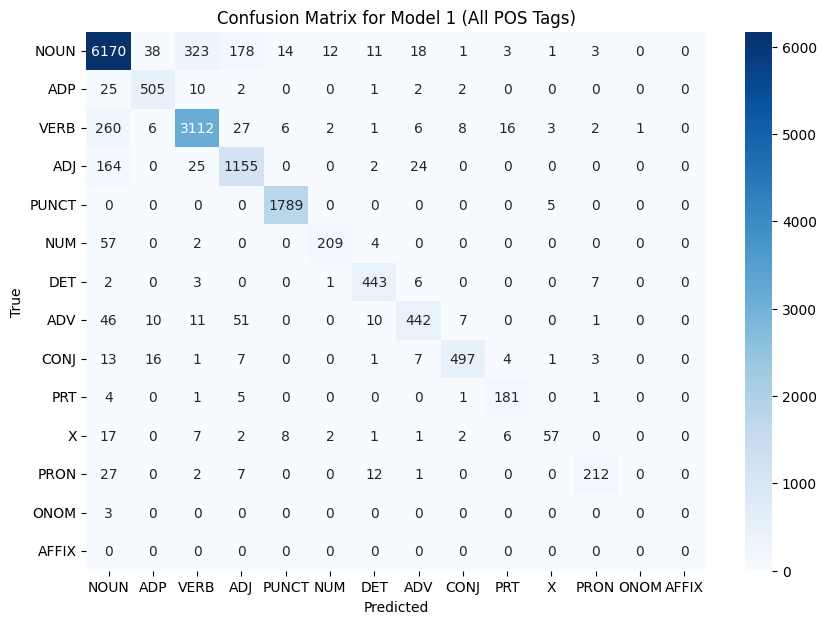


Model 2: Filtered POS Tags (ADJ, ADV, NOUN, VERB, PUNC)
Accuracy: 0.92

Classification Report:
               precision    recall  f1-score   support

         ADJ       0.82      0.83      0.83      1370
         ADV       0.90      0.79      0.84       578
        NOUN       0.92      0.93      0.93      6772
       PUNCT       0.99      1.00      0.99      1794
        VERB       0.91      0.91      0.91      3450

    accuracy                           0.92     13964
   macro avg       0.91      0.89      0.90     13964
weighted avg       0.92      0.92      0.92     13964


Confusion Matrix:

       NOUN  VERB   ADJ  PUNCT  ADV
NOUN   6302   272   167     12   19
VERB    269  3141    25      7    8
ADJ     190    19  1139      0   22
PUNCT     0     0     0   1794    0
ADV      54    12    56      0  456


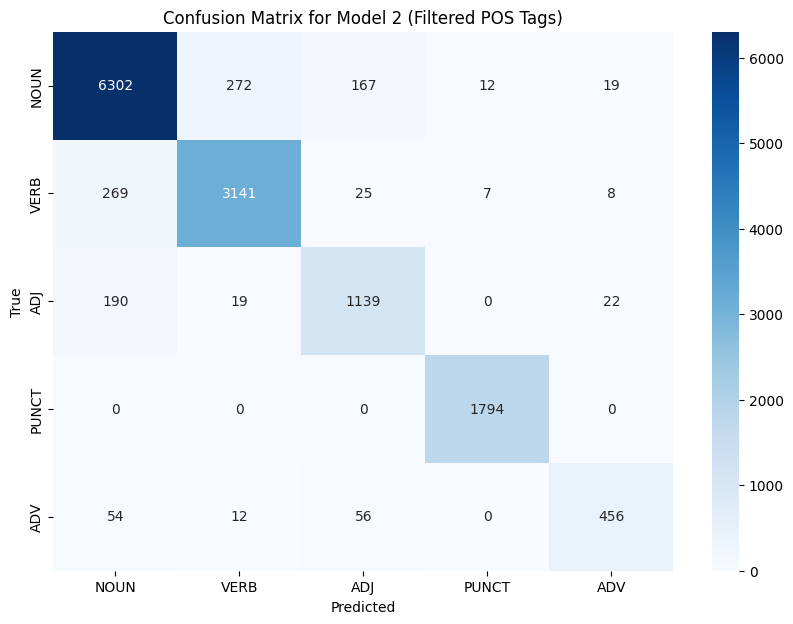

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def plot_confusion_matrix(conf_matrix, labels, model_name):
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

# Print results for Model 1
print("\nModel 1: All POS Tags")
print(f"Accuracy: {accuracy_all:.2f}")
print("\nClassification Report:\n", report_all)
print("\nConfusion Matrix:\n")
df_conf_matrix_all = pd.DataFrame(conf_matrix_all, index=labels_all, columns=labels_all)
print(df_conf_matrix_all)


plot_confusion_matrix(df_conf_matrix_all, labels_all, "Model 1 (All POS Tags)")

# Print results for Model 2
print("\nModel 2: Filtered POS Tags (ADJ, ADV, NOUN, VERB, PUNC)")
print(f"Accuracy: {accuracy_filtered:.2f}")
print("\nClassification Report:\n", report_filtered)
print("\nConfusion Matrix:\n")
df_conf_matrix_filtered = pd.DataFrame(conf_matrix_filtered, index=labels_filtered, columns=labels_filtered)
print(df_conf_matrix_filtered)


plot_confusion_matrix(df_conf_matrix_filtered, labels_filtered, "Model 2 (Filtered POS Tags)")


In [8]:
from collections import defaultdict, Counter
import math
import random
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Handle rare and unknown words
def preprocess_sentences(sentences, min_freq=2):
    word_counts = Counter(word for sentence in sentences for word, _ in sentence)
    processed_sentences = []

    for sentence in sentences:
        processed_sentence = [
            ("<RARE>" if word_counts[word] < min_freq else word, tag) for word, tag in sentence
        ]
        processed_sentences.append(processed_sentence)

    return processed_sentences

# Dictionary for open/closed class words
def build_open_closed_dict():
    open_class = {"NOUN", "VERB", "ADJ", "ADV"}
    closed_class = {"CONJ", "PRT", "ADP", "DET", "PRON", "NUM"}
    return open_class, closed_class

# Filter specific POS tags
def filter_tags(sentences, allowed_tags=None):
    if allowed_tags is None:
        return sentences
    filtered_sentences = []
    for sentence in sentences:
        filtered_sentence = [(word, pos_tag) for word, pos_tag in sentence if pos_tag in allowed_tags]
        if filtered_sentence:
            filtered_sentences.append(filtered_sentence)
    return filtered_sentences


In [9]:
# Calculate transition and emission probabilities with smoothing
def calculate_probs_with_smoothing(sentences):
    transition_counts = defaultdict(Counter)
    emission_counts = defaultdict(Counter)
    pos_tag_counts = Counter()

    for sentence in sentences:
        previous_tag = "<START>"
        pos_tag_counts[previous_tag] += 1
        for word, pos_tag in sentence:
            transition_counts[previous_tag][pos_tag] += 1
            pos_tag_counts[pos_tag] += 1
            emission_counts[pos_tag][word] += 1
            previous_tag = pos_tag
        transition_counts[previous_tag]["<END>"] += 1
        pos_tag_counts["<END>"] += 1

    transition_probs = {
        prev_tag: {tag: (count + 1) / (sum(counts.values()) + len(pos_tag_counts)) for tag, count in counts.items()}
        for prev_tag, counts in transition_counts.items()
    }

    emission_probs = {
        tag: {word: (count + 1) / (sum(counts.values()) + len(emission_counts)) for word, count in counts.items()}
        for tag, counts in emission_counts.items()
    }

    return transition_probs, emission_probs, pos_tag_counts

# Viterbi Algorithm
def viterbi_algorithm(sentence, transition_probs, emission_probs, pos_tag_counts):
    states = [state for state in pos_tag_counts.keys() if state not in ("<START>", "<END>")]
    viterbi = [{}]
    backpointer = [{}]

    for state in states:
        viterbi[0][state] = (
            math.log(transition_probs["<START>"].get(state, 1e-6))
            + math.log(emission_probs.get(state, {}).get(sentence[0], 1e-6))
        )
        backpointer[0][state] = "<START>"

    for t in range(1, len(sentence)):
        viterbi.append({})
        backpointer.append({})
        for state in states:
            max_prob, prev_state = max(
                (
                    viterbi[t - 1][prev_state]
                    + math.log(transition_probs[prev_state].get(state, 1e-6))
                    + math.log(emission_probs.get(state, {}).get(sentence[t], 1e-6)),
                    prev_state,
                )
                for prev_state in states
            )
            viterbi[t][state] = max_prob
            backpointer[t][state] = prev_state

    max_prob, last_state = max(
        (
            viterbi[len(sentence) - 1][state] + math.log(transition_probs[state].get("<END>", 1e-6)),
            state,
        )
        for state in states
    )

    best_path = [last_state]
    for t in range(len(sentence) - 1, 0, -1):
        best_path.insert(0, backpointer[t][best_path[0]])

    return best_path


In [10]:
# Evaluate Model
def evaluate_model(test_data, transition_probs, emission_probs, pos_tag_counts):
    true_tags = []
    predicted_tags = []

    for sentence in test_data:
        words = [word for word, _ in sentence]
        gold_tags = [tag for _, tag in sentence]
        pred_tags = viterbi_algorithm(words, transition_probs, emission_probs, pos_tag_counts)

        true_tags.extend(gold_tags)
        predicted_tags.extend(pred_tags)

    accuracy = accuracy_score(true_tags, predicted_tags)
    report = classification_report(true_tags, predicted_tags, zero_division=0)

    labels = list(pos_tag_counts.keys())
    if "<START>" in labels: labels.remove("<START>")
    if "<END>" in labels: labels.remove("<END>")
    conf_matrix = confusion_matrix(true_tags, predicted_tags, labels=labels)

    return accuracy, report, conf_matrix, labels


Model 1: All POS Tags
Accuracy: 0.91

Classification Report:
               precision    recall  f1-score   support

         ADJ       0.82      0.84      0.83      1370
         ADP       0.88      0.93      0.90       547
         ADV       0.87      0.76      0.81       578
        CONJ       0.95      0.91      0.93       550
         DET       0.90      0.96      0.93       462
        NOUN       0.88      0.95      0.91      6772
         NUM       0.92      0.77      0.84       272
        ONOM       0.00      0.00      0.00         3
        PRON       0.93      0.81      0.87       261
         PRT       0.86      0.94      0.90       193
       PUNCT       0.99      1.00      0.99      1794
        VERB       0.95      0.84      0.89      3450
           X       0.81      0.55      0.66       103

    accuracy                           0.91     16355
   macro avg       0.83      0.79      0.81     16355
weighted avg       0.91      0.91      0.90     16355



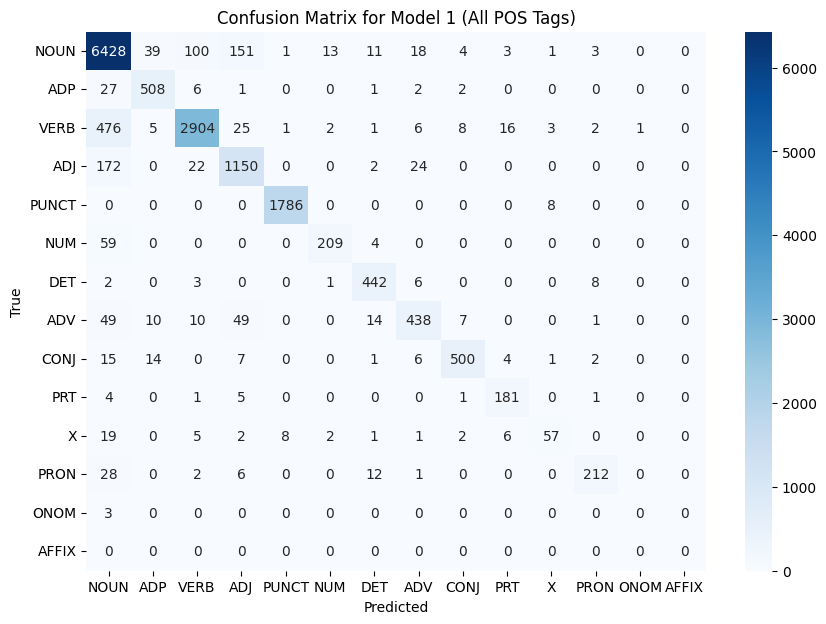


Model 2: Filtered POS Tags (ADJ, ADV, NOUN, VERB, PUNCT)
Accuracy: 0.92

Classification Report:
               precision    recall  f1-score   support

         ADJ       0.82      0.83      0.83      1370
         ADV       0.91      0.78      0.84       578
        NOUN       0.90      0.96      0.93      6772
       PUNCT       1.00      1.00      1.00      1794
        VERB       0.96      0.84      0.90      3450

    accuracy                           0.92     13964
   macro avg       0.92      0.88      0.90     13964
weighted avg       0.92      0.92      0.92     13964



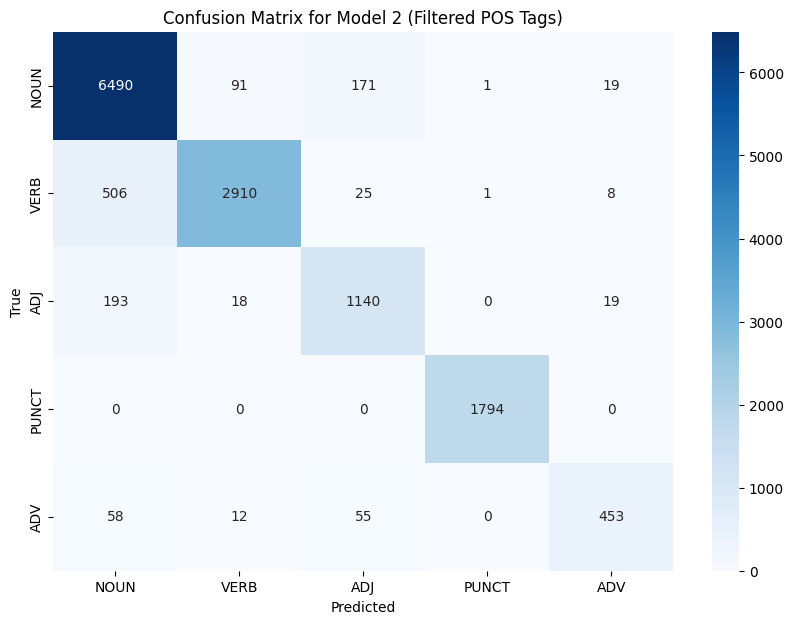

In [11]:
# Visualization
def plot_confusion_matrix(conf_matrix, labels, model_name):
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

# Main Execution
# Preprocess data
data = preprocess_sentences(all_sentences)
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Calculate probabilities for all tags
transition_probs, emission_probs, pos_tag_counts = calculate_probs_with_smoothing(train_data)

# Filtered data for specific tags
allowed_tags = ["ADJ", "ADV", "NOUN", "VERB", "PUNCT"]
filtered_train_data = filter_tags(train_data, allowed_tags)
filtered_test_data = filter_tags(test_data, allowed_tags)

# Calculate probabilities for filtered tags
filtered_transition_probs, filtered_emission_probs, filtered_pos_tag_counts = calculate_probs_with_smoothing(filtered_train_data)

# Evaluate Model 1: All Tags
accuracy_all, report_all, conf_matrix_all, labels_all = evaluate_model(
    test_data, transition_probs, emission_probs, pos_tag_counts
)

# Evaluate Model 2: Filtered Tags
accuracy_filtered, report_filtered, conf_matrix_filtered, labels_filtered = evaluate_model(
    filtered_test_data, filtered_transition_probs, filtered_emission_probs, filtered_pos_tag_counts
)

# Results for Model 1
print("\nModel 1: All POS Tags")
print(f"Accuracy: {accuracy_all:.2f}")
print("\nClassification Report:\n", report_all)
plot_confusion_matrix(conf_matrix_all, labels_all, "Model 1 (All POS Tags)")

# Results for Model 2
print("\nModel 2: Filtered POS Tags (ADJ, ADV, NOUN, VERB, PUNCT)")
print(f"Accuracy: {accuracy_filtered:.2f}")
print("\nClassification Report:\n", report_filtered)
plot_confusion_matrix(conf_matrix_filtered, labels_filtered, "Model 2 (Filtered POS Tags)")


# Data Preprocessing Method
Web and wiki datasets were combined to create a larger data pool. This dataset was randomly split into 80% training and 20% testing. A fixed random seed was used to make this split repeatable. Additionally, `<START>` and `<END>` tags were added to each sentence.

# Calculating MLE Probabilities for Transition and Emission Matrices
Transition and emission probabilities were calculated using the Maximum Likelihood Estimation method. Transition probabilities were calculated by normalizing the number of transitions from one POS tag to another. Spreading probabilities were obtained from the matching frequency of each POS tag with a word. Smoothing was applied to the model with a small epsilon value to solve the zero probability problem.

# Challanges
Some errors occurred while correctly integrating the `<START>` and `<END>` tags into the transition and propagation possibilities. These problems were carefully resolved.Although the optimization attempts made during the development of the model did not increase the overall accuracy much, they did provide a noticeable performance increase for certain POS tags (e.g. `NOUN`, `VERB`).

# Comments
- **Model 1:** It provided a wide coverage by predicting all POS tags and achieved 90% accuracy.
- **Model 2:** It achieved 92% accuracy by working with specific tags (`ADJ`, `ADV`, `NOUN`, `VERB`, `PUNCT`). It showed higher performance for common tags (e.g. `NOUN`, `VERB`).

# Limitations
Improvement efforts such as filtering and handling rare words resulted in significant improvements for some POS tags (e.g. `NOUN` and `VERB`), but only increased the overall accuracy from 90% to 91% and 92%, thus not producing as large an increase as expected.

# Possible Improvements
Using Transformer-based models (e.g. BERT) the contextual relationships of words can be learned and integrated into the HMM model.
Rules that take into account grammatical relationships within the sentence (e.g. subject-verb agreement) can be integrated.
Using trigram or higher n-gram models can capture more complex contextual relationships between POS tags
